In [1]:
data_path = r"D:\Downloads\Final\EuroSAT_MS\EuroSAT_MS"

In [2]:
import os

print(os.listdir(data_path))

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [3]:
import os
import rasterio
import numpy as np

images = []
labels = []

for folder in os.listdir(data_path):
    folder_path = os.path.join(data_path, folder)
    
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        
        with rasterio.open(img_path) as src:
            img = src.read()  
        
        images.append(img)
        labels.append(folder)

images = np.array(images)
labels = np.array(labels)

print(images.shape)

(27000, 13, 64, 64)


In [4]:
import pandas as pd

df = pd.DataFrame(labels, columns=["label"])
print(df["label"].value_counts())

label
AnnualCrop              3000
Forest                  3000
HerbaceousVegetation    3000
Residential             3000
SeaLake                 3000
Highway                 2500
Industrial              2500
PermanentCrop           2500
River                   2500
Pasture                 2000
Name: count, dtype: int64


In [5]:
import numpy as np
from collections import Counter

counts = Counter(labels)
total = len(labels)

for c in sorted(counts.keys()):
    print(f"{c}: {counts[c]} samples ({counts[c]/total*100:.2f}%)")

AnnualCrop: 3000 samples (11.11%)
Forest: 3000 samples (11.11%)
HerbaceousVegetation: 3000 samples (11.11%)
Highway: 2500 samples (9.26%)
Industrial: 2500 samples (9.26%)
Pasture: 2000 samples (7.41%)
PermanentCrop: 2500 samples (9.26%)
Residential: 3000 samples (11.11%)
River: 2500 samples (9.26%)
SeaLake: 3000 samples (11.11%)


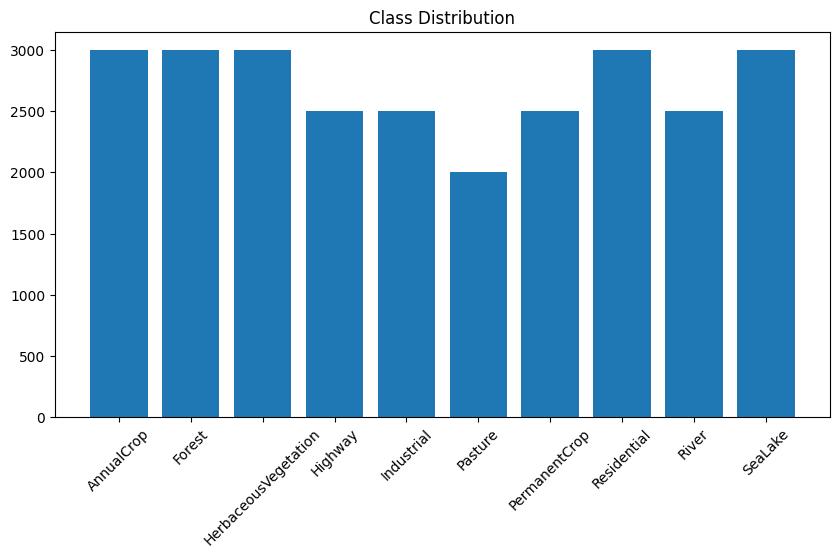

In [6]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

counts = Counter(labels)

classes = sorted(list(set(labels)))

plt.figure(figsize=(10,5))
plt.bar(classes, [counts[c] for c in classes])
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def get_rgb(img):

    rgb = img[[3, 2, 1]].astype(np.float32)

    p2, p98 = np.percentile(rgb, (2, 98))

    rgb = np.clip(rgb, p2, p98)

    rgb = (rgb - p2) / (p98 - p2 + 1e-8)

    return rgb.transpose(1, 2, 0)

In [8]:
def show_image(img, title=None):
    rgb = get_rgb(img)

    plt.imshow(rgb)
    plt.axis("off")

    if title:
        plt.title(title)

    plt.show()

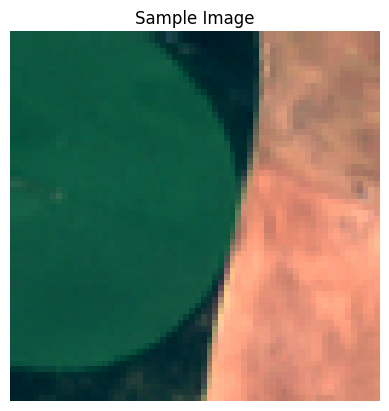

In [9]:
show_image(images[1], "Sample Image")

In [10]:
for i in range(13):
    band = images[:, i, :, :].ravel()
    print(f"Band {i}: min={band.min()}, max={band.max()}, mean={band.mean()}")

Band 0: min=808, max=17720, mean=1353.7269257269966
Band 1: min=0, max=28000, mean=1117.2022923538773
Band 2: min=0, max=28000, mean=1041.8847248444733
Band 3: min=0, max=28000, mean=946.5542548737702
Band 4: min=174, max=24008, mean=1199.1886644965277
Band 5: min=153, max=27791, mean=2003.0067999403211
Band 6: min=128, max=28001, mean=2374.0084444173176
Band 7: min=0, max=28003, mean=2301.22043838614
Band 8: min=40, max=15384, mean=732.1819500777633
Band 9: min=1, max=183, mean=12.099527624059606
Band 10: min=5, max=24704, mean=1820.6963774866174
Band 11: min=1, max=22210, mean=1118.2027229275175
Band 12: min=91, max=28000, mean=2599.7829372558595


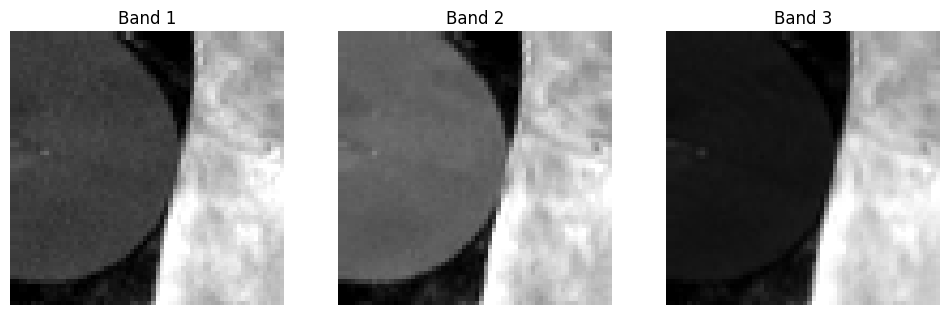

In [11]:
fig, ax = plt.subplots(1,3, figsize=(12,4))

for i, b in enumerate([1,2,3]):
    band = images[1][b].astype(float)

    low, high = np.percentile(band, (2,98))
    band = np.clip(band, low, high)
    band = (band - band.min()) / (band.max() - band.min() + 1e-8)

    ax[i].imshow(band, cmap="gray")
    ax[i].set_title(f"Band {b}")
    ax[i].axis("off")

plt.show()

In [12]:
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Number of classes:", len(set(labels)))
print("Unique classes:", sorted(set(labels)))

Images shape: (27000, 13, 64, 64)
Labels shape: (27000,)
Number of classes: 10
Unique classes: [np.str_('AnnualCrop'), np.str_('Forest'), np.str_('HerbaceousVegetation'), np.str_('Highway'), np.str_('Industrial'), np.str_('Pasture'), np.str_('PermanentCrop'), np.str_('Residential'), np.str_('River'), np.str_('SeaLake')]


In [13]:
import numpy as np

print("Missing values in images:", np.isnan(images).sum())

Missing values in images: 0


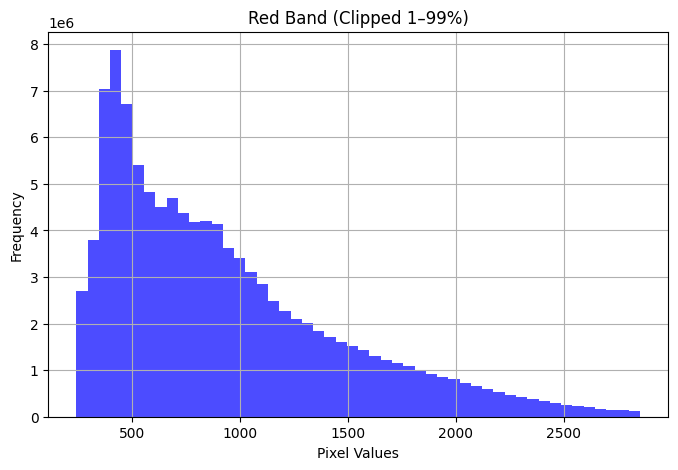

In [14]:
band = images[:, 3, :, :].ravel()

p1, p99 = np.percentile(band, (1, 99))
band = band[(band >= p1) & (band <= p99)]

plt.figure(figsize=(8,5))
plt.hist(band, bins=50, color="blue", alpha=0.7)
plt.title("Red Band (Clipped 1–99%)")
plt.xlabel("Pixel Values")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

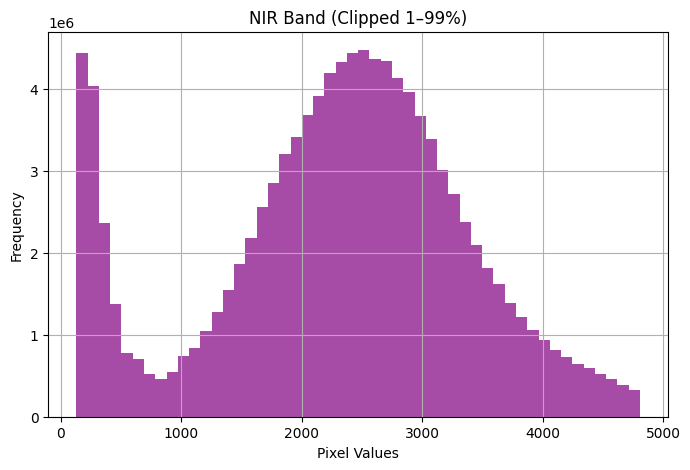

In [15]:
band = images[:, 7, :, :].ravel()

p1, p99 = np.percentile(band, (1, 99))
band = band[(band >= p1) & (band <= p99)]

plt.figure(figsize=(8,5))
plt.hist(band, bins=50, color="purple", alpha=0.7)
plt.title("NIR Band (Clipped 1–99%)")
plt.xlabel("Pixel Values")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

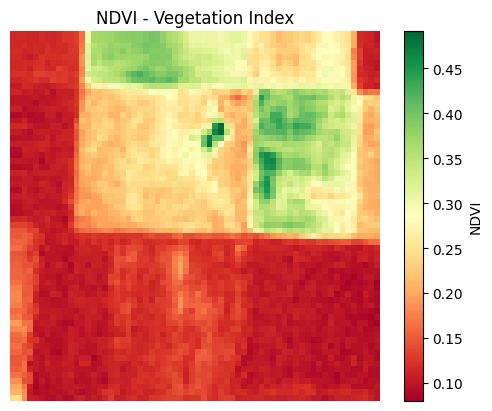

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def ndvi(img):
    red = img[3].astype(np.float32)
    nir = img[7].astype(np.float32)

    ndvi = (nir - red) / (nir + red + 1e-8)

    return np.clip(ndvi, -1, 1)

plt.imshow(ndvi(images[0]), cmap="RdYlGn")
plt.colorbar(label="NDVI")
plt.title("NDVI - Vegetation Index")
plt.axis("off")
plt.show()

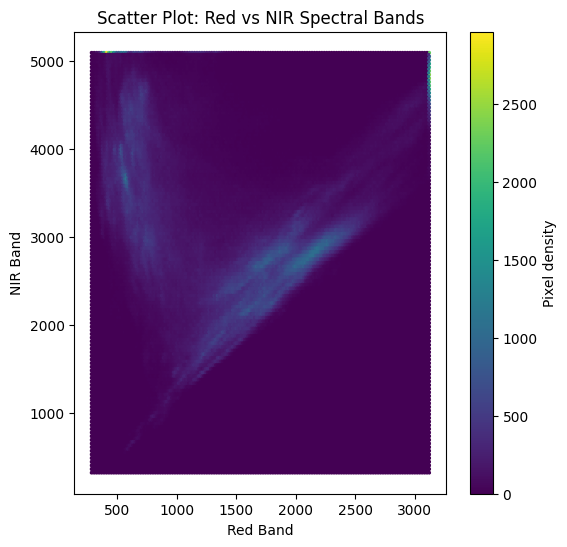

In [17]:
import matplotlib.pyplot as plt

sample = images[:1000]

red = sample[:, 3, :, :].ravel()
nir = sample[:, 7, :, :].ravel()

red = np.clip(red, 0, np.percentile(red, 99))
nir = np.clip(nir, 0, np.percentile(nir, 99))

plt.figure(figsize=(6,6))
plt.hexbin(red, nir, gridsize=200, cmap='viridis')
plt.colorbar(label="Pixel density")

plt.xlabel("Red Band")
plt.ylabel("NIR Band")
plt.title("Scatter Plot: Red vs NIR Spectral Bands")

plt.show()

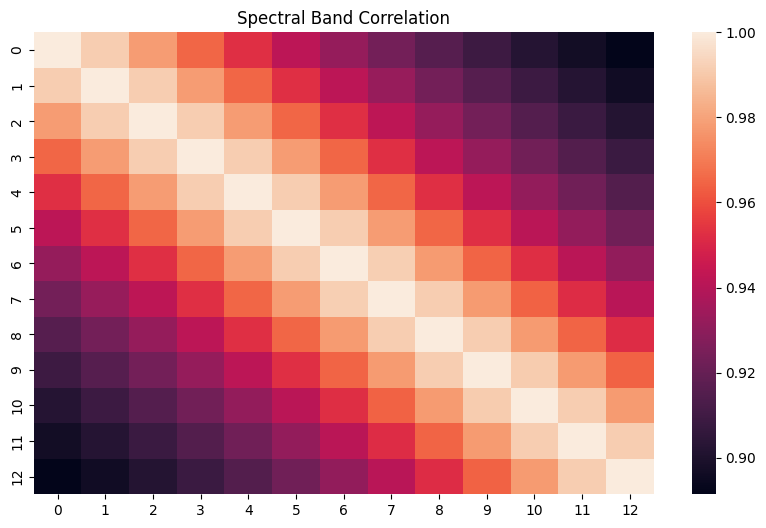

In [18]:
import seaborn as sns

sample = images[:100]

flat = images.reshape(-1, images.shape[1])
df = pd.DataFrame(flat)

plt.figure(figsize=(10,6))
sns.heatmap(df.corr())
plt.title("Spectral Band Correlation")
plt.show()

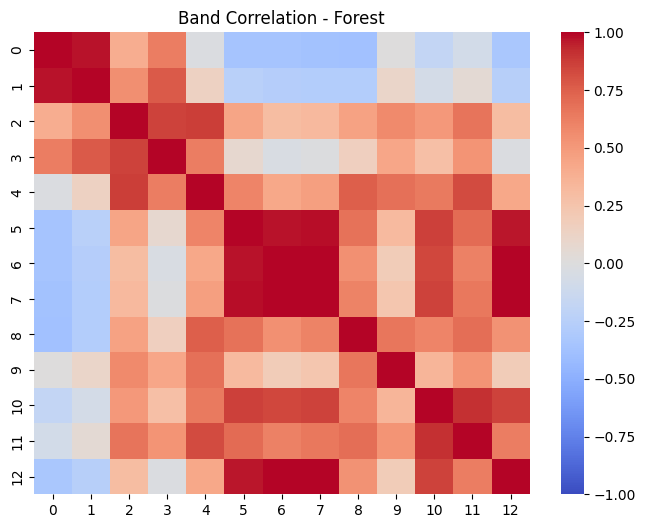

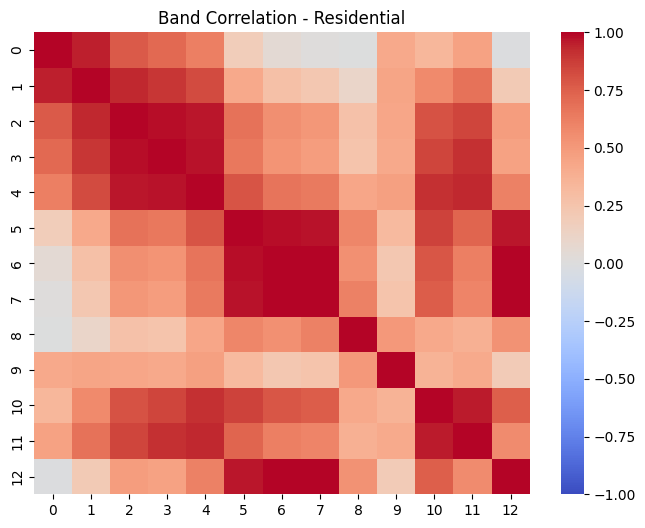

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_class_corr(class_name):
    idx = np.where(np.array(labels) == class_name)[0]
    imgs = images[idx]

    band_means = imgs.mean(axis=(2,3)) 

    df = pd.DataFrame(band_means)
    corr = df.corr()

    plt.figure(figsize=(8,6))
    sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1, center=0)

    plt.title(f"Band Correlation - {class_name}")
    plt.show()

plot_class_corr("Forest")
plot_class_corr("Residential")

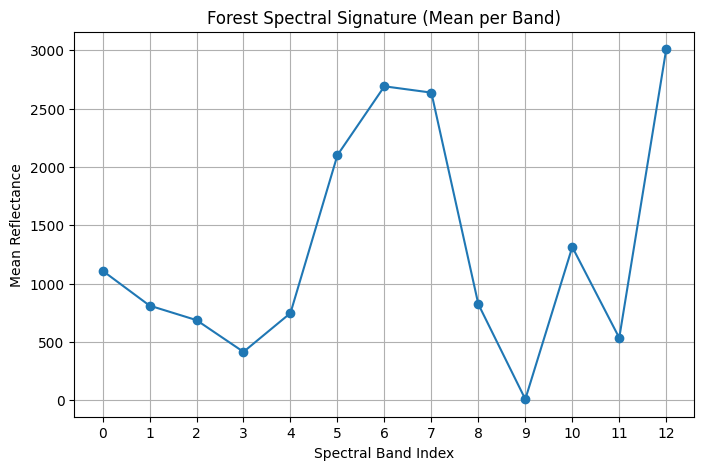

In [20]:
plt.figure(figsize=(8,5))

bands = images[labels == "Forest"].mean(axis=(0,2,3))

plt.plot(bands, marker='o')
plt.xticks(range(len(bands)))
plt.title("Forest Spectral Signature (Mean per Band)", fontsize=12)
plt.xlabel("Spectral Band Index")
plt.ylabel("Mean Reflectance")
plt.grid()

plt.show()

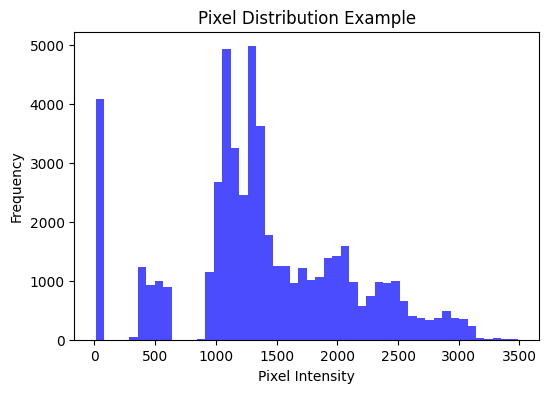

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def plot_hist(img, title=""):
    plt.figure(figsize=(6,4))
    plt.hist(img.flatten(), bins=50, color='blue', alpha=0.7)
    plt.title(title)
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.show()

plot_hist(images[0], "Pixel Distribution Example")

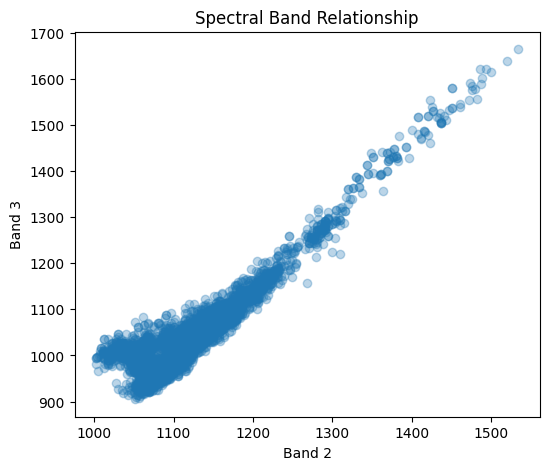

In [22]:
def scatter_bands(img):
    plt.figure(figsize=(6,5))
    
    band1 = img[1].flatten()
    band2 = img[2].flatten()
    
    plt.scatter(band1[:5000], band2[:5000], alpha=0.3)
    plt.xlabel("Band 2")
    plt.ylabel("Band 3")
    plt.title("Spectral Band Relationship")
    plt.show()

scatter_bands(images[0])

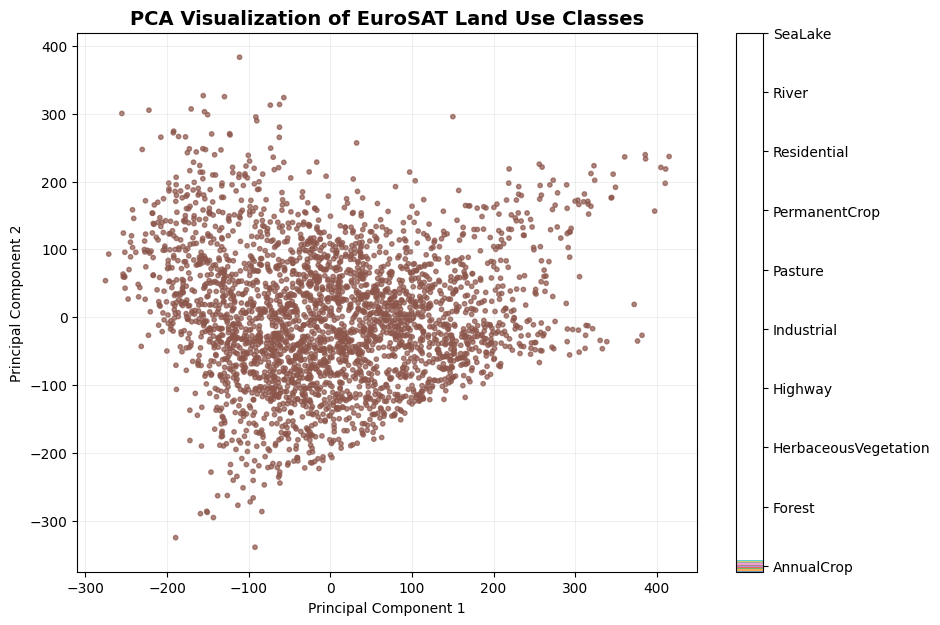

In [23]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np

X = images.reshape(len(images), -1).astype(np.float32)

le = LabelEncoder()
y = le.fit_transform(labels)

X_small = X[:3000]
y_small = y[:3000]

scaler = StandardScaler()
X_small_scaled = scaler.fit_transform(X_small)

pca_50 = PCA(n_components=50, random_state=42)
X_mid = pca_50.fit_transform(X_small_scaled)

pca_2 = PCA(n_components=2, random_state=42)
X_pca = pca_2.fit_transform(X_mid)

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_small,
    cmap='tab10',
    s=10,
    alpha=0.7
)

cbar = plt.colorbar(scatter)
cbar.set_ticks(range(len(le.classes_)))
cbar.set_ticklabels(le.classes_)

plt.title("PCA Visualization of EuroSAT Land Use Classes",
          fontsize=14, fontweight='bold')

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(alpha=0.2)
plt.show()

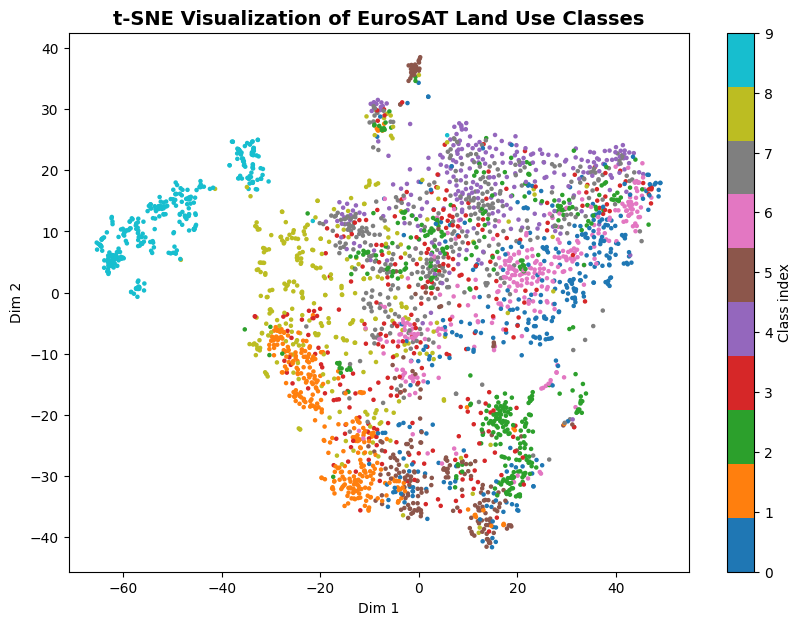

In [24]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

sample_size = 3000
idx = np.random.choice(len(images), sample_size, replace=False)

X_sample = images[idx].reshape(sample_size, -1).astype(np.float32)
y_sample = y[idx]

X_sample = StandardScaler().fit_transform(X_sample)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(10,7))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_sample, cmap='tab10', s=5)

cbar = plt.colorbar()
cbar.set_label("Class index")
cbar.set_ticks(range(len(set(y_sample))))

plt.title("t-SNE Visualization of EuroSAT Land Use Classes", fontsize=14, fontweight='bold')
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

plt.show()

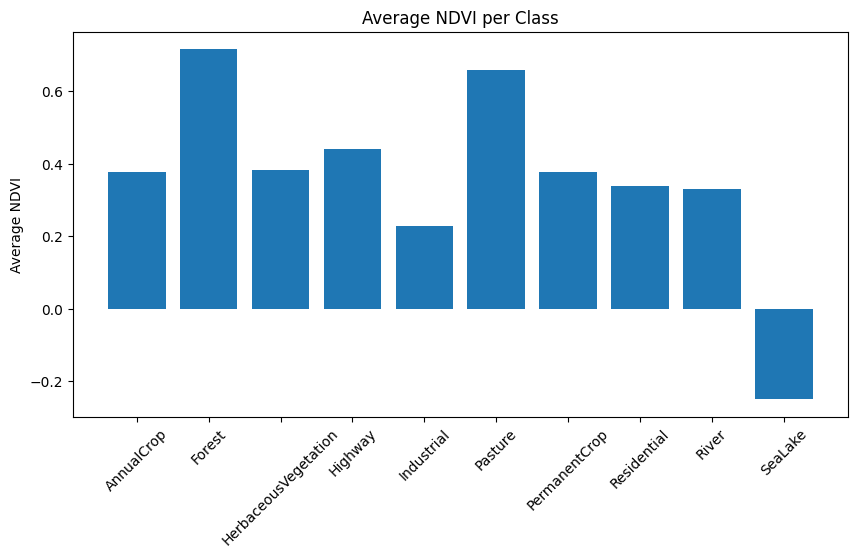

In [25]:
import numpy as np
import matplotlib.pyplot as plt

ndvi_means = []

for c in classes:
    idx = np.array(labels) == c
    class_imgs = images[idx][:200]

    red = class_imgs[:, 3, :, :].astype(np.float32)
    nir = class_imgs[:, 7, :, :].astype(np.float32)

    ndvi = (nir - red) / (nir + red + 1e-8)

    ndvi_means.append(ndvi.mean())

plt.figure(figsize=(10,5))
plt.bar(classes, ndvi_means)

plt.xticks(rotation=45)
plt.ylabel("Average NDVI")
plt.title("Average NDVI per Class")

plt.show()

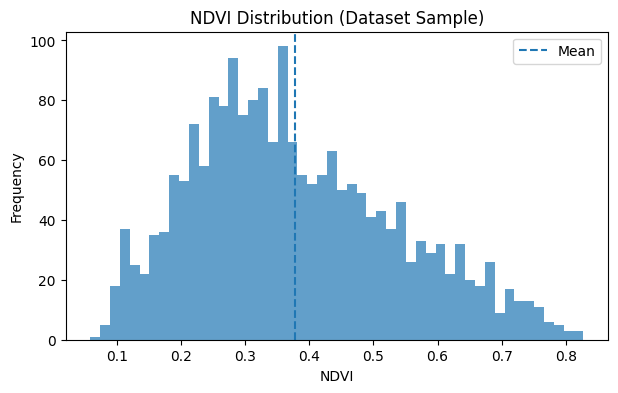

In [26]:
red = images[:2000, 3, :, :].astype(np.float32)
nir = images[:2000, 7, :, :].astype(np.float32)

ndvi = (nir - red) / (nir + red + 1e-8)

ndvi_vals = ndvi.mean(axis=(1,2))

plt.figure(figsize=(7,4)) 

plt.hist(ndvi_vals, bins=50, alpha=0.7)

plt.axvline(ndvi_vals.mean(), linestyle='--', label='Mean')

plt.title("NDVI Distribution (Dataset Sample)")
plt.xlabel("NDVI")
plt.ylabel("Frequency")

plt.legend()
plt.show()

In [27]:
def avg_class(class_name):

    idx = np.array(labels) == class_name
    imgs = images[idx]

    if len(imgs) == 0:
        print("No images found for", class_name)
        return

    avg = imgs.mean(axis=0)

    rgb = np.stack([avg[4], avg[3], avg[2]], axis=2)

    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

    plt.imshow(rgb)
    plt.title(class_name)
    plt.axis("off")
    plt.show()

In [28]:
def ndvi(img):
    red = img[3].astype(float)
    nir = img[7].astype(float)
    return (nir - red) / (nir + red + 1e-8)

In [29]:
def class_ndvi(class_name):

    idx = np.array(labels) == class_name  
    imgs = images[idx]

    print(class_name, "images:", len(imgs))

    if len(imgs) == 0:
        return

    ndvi_vals = [ndvi(img).mean() for img in imgs[:200]]

    plt.hist(ndvi_vals, bins=30)
    plt.title(f"NDVI Distribution - {class_name}")
    plt.show()

Forest images: 3000


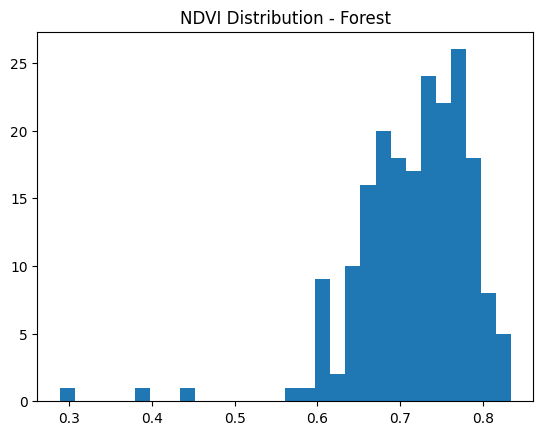

Residential images: 3000


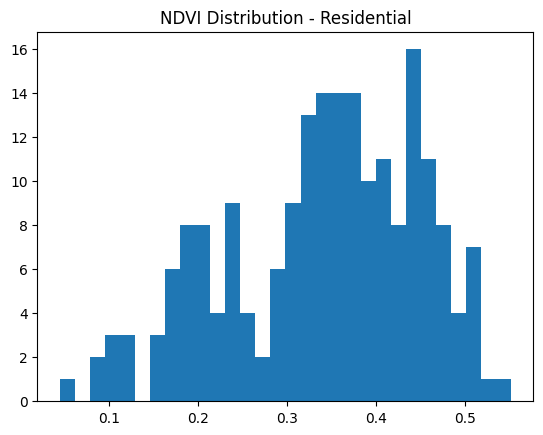

In [30]:
class_ndvi("Forest")
class_ndvi("Residential")

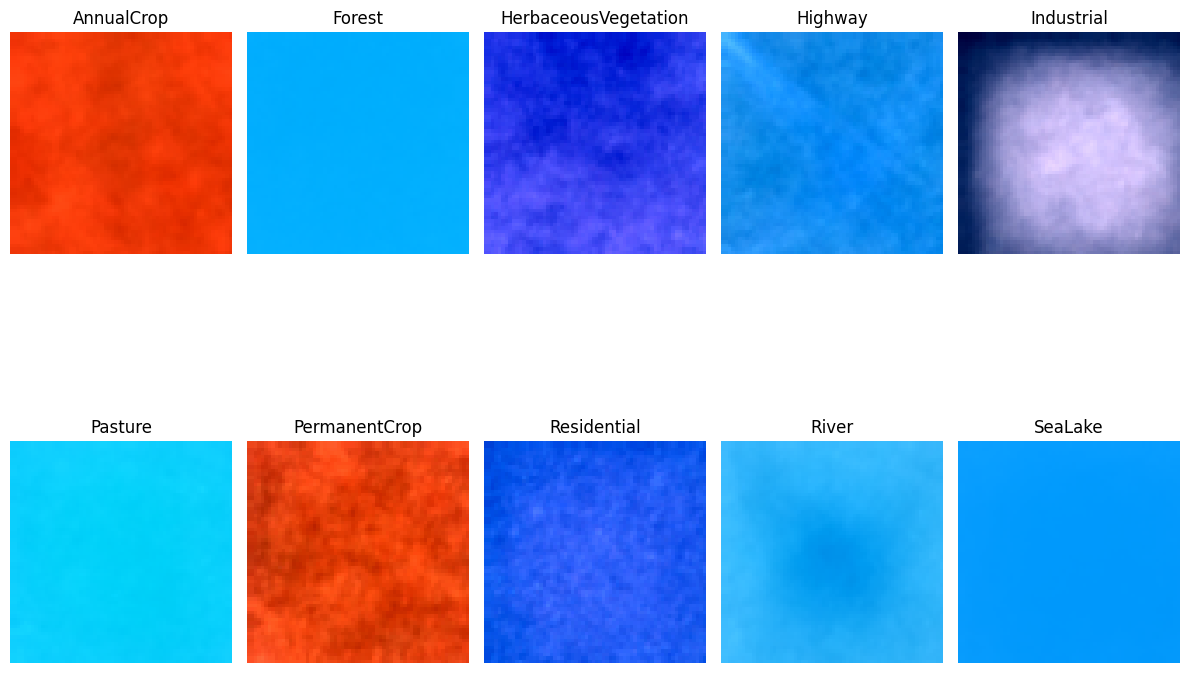

In [31]:
plt.figure(figsize=(12,10))

for i, c in enumerate(classes):
    plt.subplot(2,5,i+1)

    idx = np.array(labels) == c
    avg = images[idx].mean(axis=0)

    rgb = np.stack([avg[3], avg[2], avg[1]], axis=2)
    p2, p98 = np.percentile(rgb, (2, 98))
    rgb = np.clip(rgb, p2, p98)
    rgb = (rgb - p2) / (p98 - p2 + 1e-8)

    plt.imshow(rgb)
    plt.title(c)
    plt.axis("off")

plt.tight_layout()
plt.show()

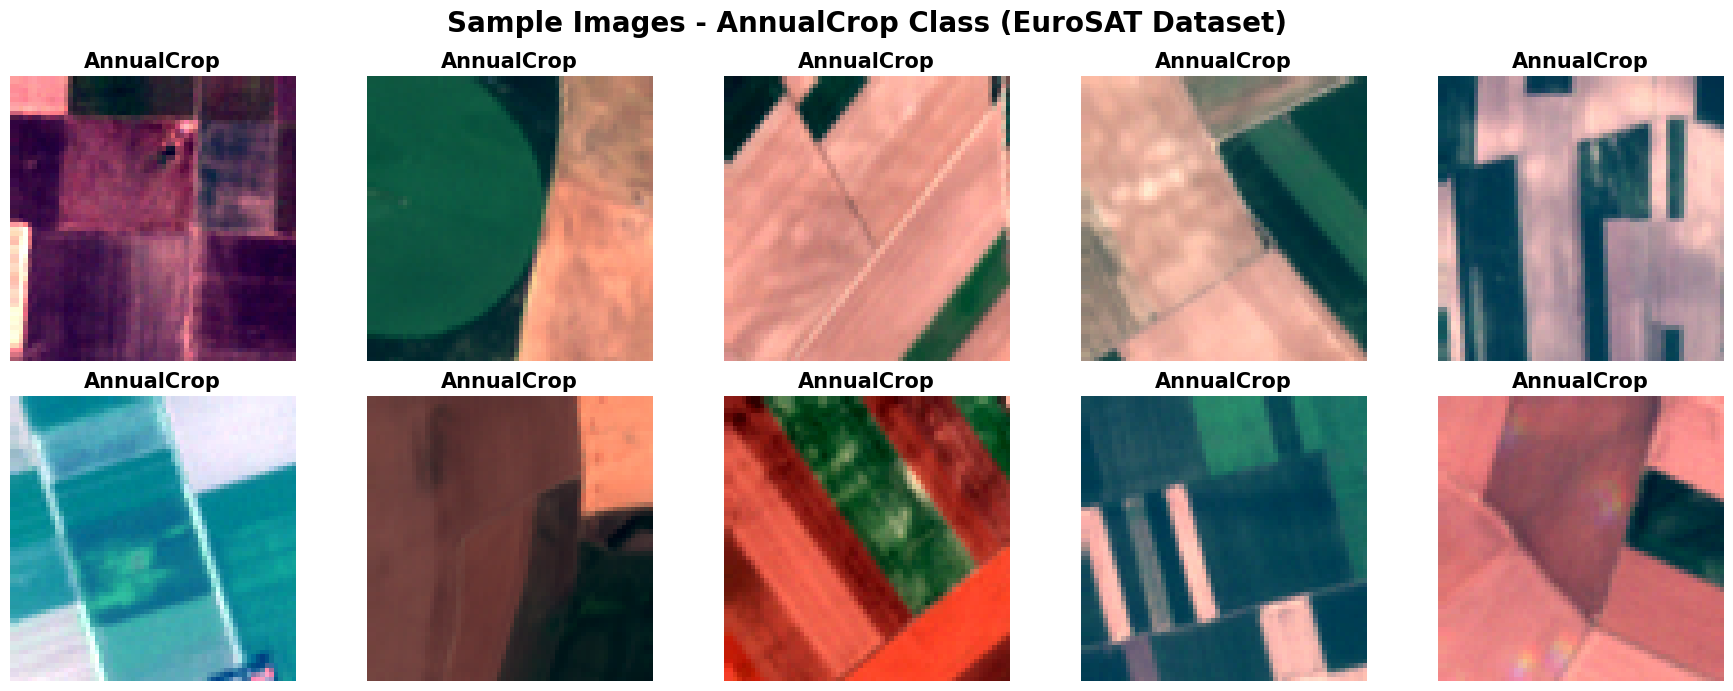

In [32]:
import matplotlib.pyplot as plt
import numpy as np

def get_rgb(img):
    rgb = img[[3,2,1]].astype(np.float32)

    p2, p98 = np.percentile(rgb, (2, 98))
    rgb = np.clip(rgb, p2, p98)
    rgb = (rgb - p2) / (p98 - p2 + 1e-8)

    return rgb.transpose(1,2,0)

class_name = "AnnualCrop"
idxs = np.where(np.array(labels) == class_name)[0][:10]

fig, axs = plt.subplots(2, 5, figsize=(18, 7))

for i, ax in enumerate(axs.flatten()):
    ax.imshow(get_rgb(images[idxs[i]]))
    
    ax.set_title(class_name, fontsize=15, fontweight='bold')
    ax.axis("off")

plt.suptitle(
    "Sample Images - AnnualCrop Class (EuroSAT Dataset)",
    fontsize=20,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig("annualcrop_samples.png", dpi=300, bbox_inches="tight")
plt.show()


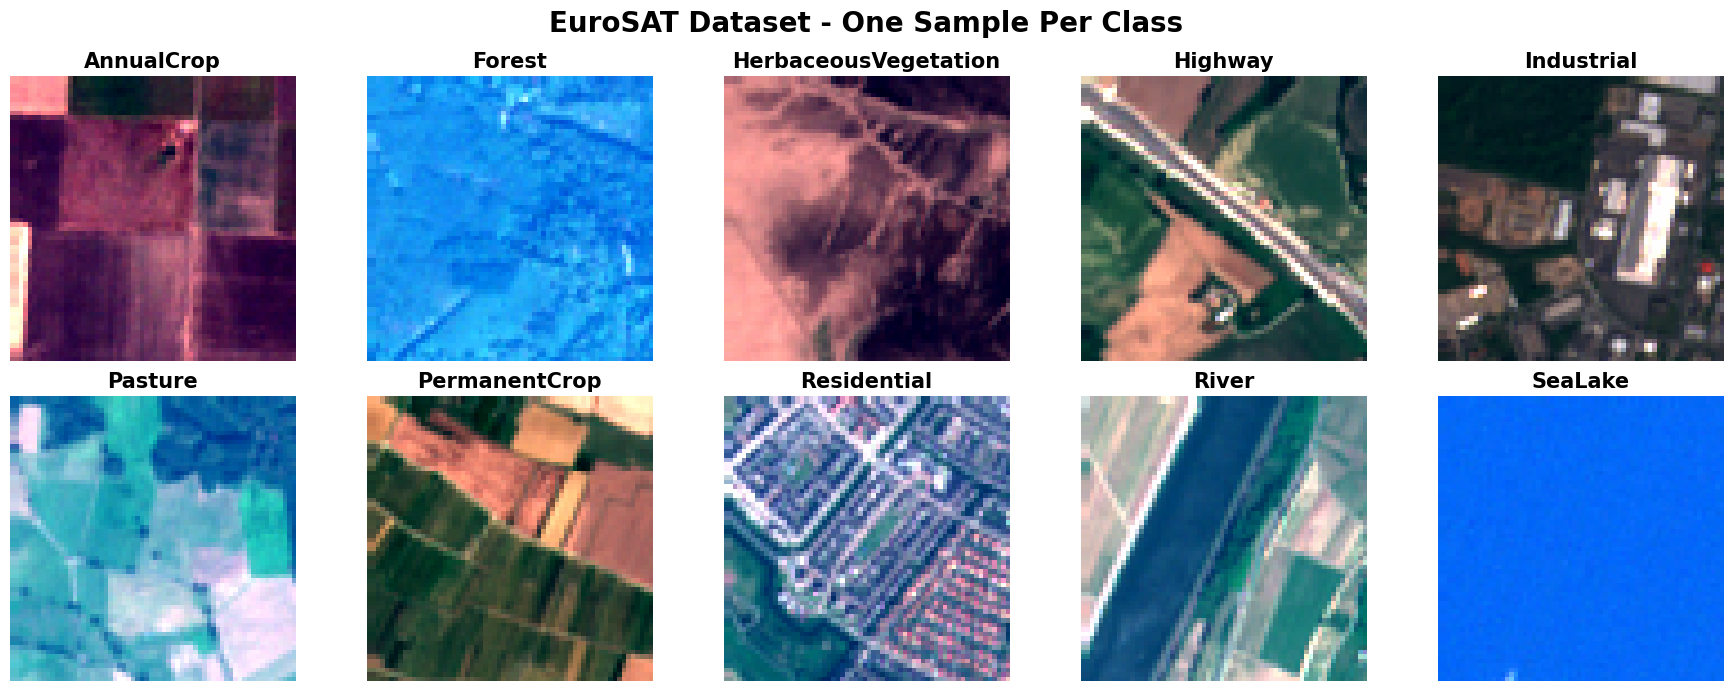

In [33]:
import matplotlib.pyplot as plt
import numpy as np

def get_rgb(img):
    rgb = img[[3,2,1]].astype(np.float32)

    p2, p98 = np.percentile(rgb, (2, 98))
    rgb = np.clip(rgb, p2, p98)
    rgb = (rgb - p2) / (p98 - p2 + 1e-8)

    return rgb.transpose(1,2,0)

sample_indices = []

for c in classes:
    idx = np.where(np.array(labels) == c)[0][0]
    sample_indices.append(idx)

fig, axs = plt.subplots(2, 5, figsize=(18, 7))

for i, ax in enumerate(axs.flatten()):
    img = images[sample_indices[i]]
    
    ax.imshow(get_rgb(img))
    ax.set_title(classes[i], fontsize=15, fontweight='bold')
    ax.axis("off")

plt.suptitle("EuroSAT Dataset - One Sample Per Class", fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("eurosat_samples.png", dpi=300, bbox_inches="tight")
plt.show()
